## "ANALISIS DE VENTAS CON PYTHON"

# OBJETIVO: Analizar un Data Set de Ventas para indentificar patrones, tendencias y oportunidades de mejora en el negocio

### DESARROLLO DEL PROYECTO

In [5]:
# importando librerias
import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_csv("ventas_dataset.csv")

# Ver primeras filas
df.head()

,fecha_venta,producto,categoria,cantidad,precio_unitario,cliente,ciudad,total_venta
0,2023-04-13,Mouse,Tecnología,5,3324.08,Cliente_9,Toluca,16620.40
1,2023-09-28,Teclado,Tecnología,3,16846.44,Cliente_17,Puebla,50539.32
2,2023-04-17,Mouse,Accesorios,5,16943.52,Cliente_12,Puebla,84717.60
3,2023-03-13,Mouse,Accesorios,5,19109.20,Cliente_14,Monterrey,95546.00
4,2023-07-08,Mouse,Tecnología,5,3177.98,Cliente_15,Guadalajara,15889.90


In [ ]:
# EXPLORACION INICIAL DE LOS DATOS

df.info() # para verificar los tipos de datos
df.describe() # observar la estadistica max, min, promedio, etc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha_venta      300 non-null    object 
 1   producto         300 non-null    object 
 2   categoria        300 non-null    object 
 3   cantidad         300 non-null    int64  
 4   precio_unitario  300 non-null    float64
 5   cliente          300 non-null    object 
 6   ciudad           300 non-null    object 
 7   total_venta      300 non-null    float64
dtypes: float64(2), int64(1), object(5)
memory usage: 18.9+ KB


,cantidad,precio_unitario,total_venta
count,300.000000,300.000000,300.000000
mean,4.960000,10235.517900,52213.973233
std,2.537689,6085.630033,43223.701214
min,1.000000,104.730000,209.460000
25%,3.000000,4809.530000,14455.060000
50%,5.000000,10497.290000,45224.440000
75%,7.000000,15451.735000,79912.092500
max,9.000000,19987.130000,178063.020000


### LIMPIEZA DE DATOS

In [ ]:
# Convertir a fecha para poder analizarlas

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])

# Verificar valores nulos o faltantes
df.isnull().sum()

# Crear columna total (por si no existiera) para analizar el total de cada venta
df['total_venta'] = df['cantidad'] * df['precio_unitario']

df.head()


,fecha_venta,producto,categoria,cantidad,precio_unitario,cliente,ciudad,total_venta
0,2023-04-13,Mouse,Tecnología,5,3324.08,Cliente_9,Toluca,16620.40
1,2023-09-28,Teclado,Tecnología,3,16846.44,Cliente_17,Puebla,50539.32
2,2023-04-17,Mouse,Accesorios,5,16943.52,Cliente_12,Puebla,84717.60
3,2023-03-13,Mouse,Accesorios,5,19109.20,Cliente_14,Monterrey,95546.00
4,2023-07-08,Mouse,Tecnología,5,3177.98,Cliente_15,Guadalajara,15889.90


### ANALISIS DE DATOS

In [15]:
# Analisis para ver cuanto dinero genero el negocio
ventas_totales = df['total_venta'].sum()
print("Ventas totales:", ventas_totales)

Ventas totales: 15664191.969999999


In [17]:
#Verificar productos mas vendidos

ventas_producto = df.groupby('producto')['total_venta'].sum().sort_values(ascending=False) 
print(ventas_producto)
#groupby lo utilice para agrupar por producto
#sum para sumal el total de ventas por cada producto
#sort_values para ordenar de mayor a menor

producto
Audífonos    3355854.25
Monitor      3272892.08
Mouse        3268592.00
Laptop       3107714.09
Teclado      2659139.55
Name: total_venta, dtype: float64


In [18]:
# VENTAS POR CIUDAD
ventas_ciudad = df.groupby('ciudad')['total_venta'].sum().sort_values(ascending=False)
print(ventas_ciudad)

ciudad
Toluca         3784922.22
Puebla         3732863.02
Monterrey      3082288.87
Guadalajara    3006816.11
CDMX           2057301.75
Name: total_venta, dtype: float64


In [ ]:
#TENDENCIAS DE VENTAS POR FECHA Y COMO VAN CAMBIANDO LAS FECHAS CON EL TIEMPO
ventas_fecha = df.groupby('fecha_venta')['total_venta'].sum()
print(ventas_fecha)


fecha_venta
2023-01-02    224895.05
2023-01-04     54771.00
2023-01-05    153061.36
2023-01-06       747.06
2023-01-09    172745.84
                ...    
2023-10-20     85355.75
2023-10-21     42726.06
2023-10-22     35339.66
2023-10-23     24447.78
2023-10-25     75493.05
Name: total_venta, Length: 181, dtype: float64


### VISUALIZACIONES

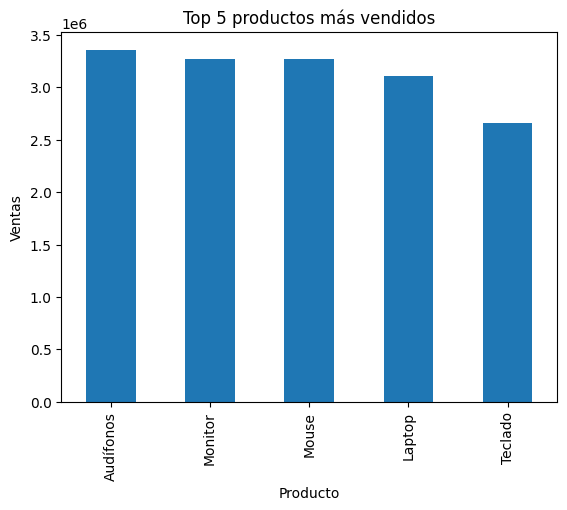

In [21]:
# tOP DEL PRODUCTO MAS VENDIDO
ventas_producto.head(5).plot(kind='bar')
plt.title("Top 5 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Ventas")
plt.show()

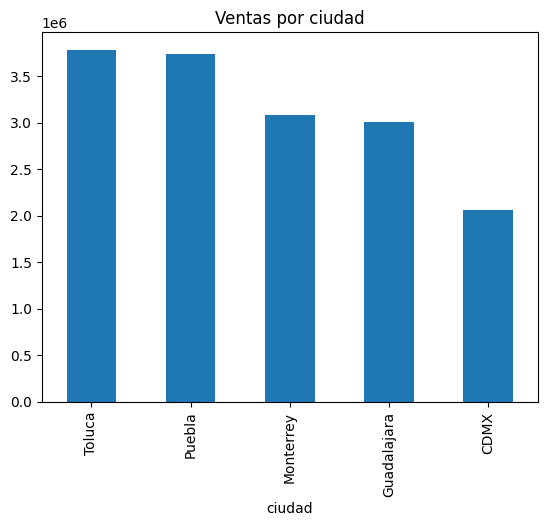

In [22]:
# VENTAS POR CIUDAD
ventas_ciudad.plot(kind='bar')
plt.title("Ventas por ciudad")
plt.show()

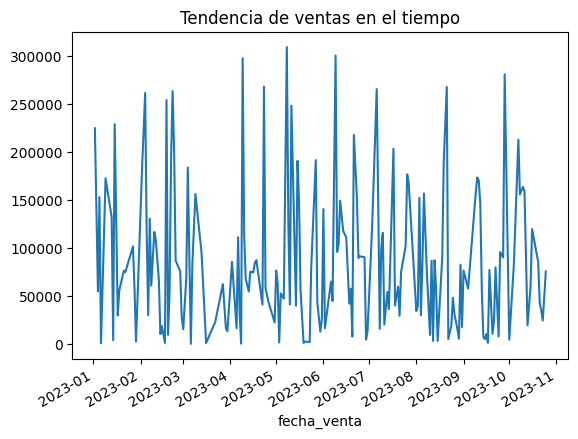

In [23]:
# TENDENCIAS DE VENTAS POR FECHA
ventas_fecha.plot()
plt.title("Tendencia de ventas en el tiempo")
plt.show()

En este grafico si sube las lineas significa que hay un crecimeinto en las ventas y si baja existe algun 
problema en las ventas.

In [24]:
#Analisis por mes
df['mes'] = df['fecha_venta'].dt.month
df.groupby('mes')['total_venta'].sum()

mes
1     1370406.36
2     2271397.16
3      721091.67
4     1536114.26
5     1760966.32
6     1914200.73
7     1732151.47
8     1587816.68
9     1528412.90
10    1241634.42
Name: total_venta, dtype: float64